## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

## Load Cleaned Dataset

In [4]:
# Load cleaned dataset
df = pd.read_csv('../data/data_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Identify column types
numerical_cols = df.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Dataset shape: (45194, 15)

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Numerical columns (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns (9): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


## Target Variable Analysis

In [5]:
# Target variable distribution
target_counts = df['income'].value_counts()
target_percent = df['income'].value_counts(normalize=True) * 100

print(f"Income distribution:")
for category, count in target_counts.items():
    percentage = target_percent[category]
    print(f"  {category}: {count:,} ({percentage:.1f}%)")

Income distribution:
  <=50K: 33,988 (75.2%)
  >50K: 11,206 (24.8%)


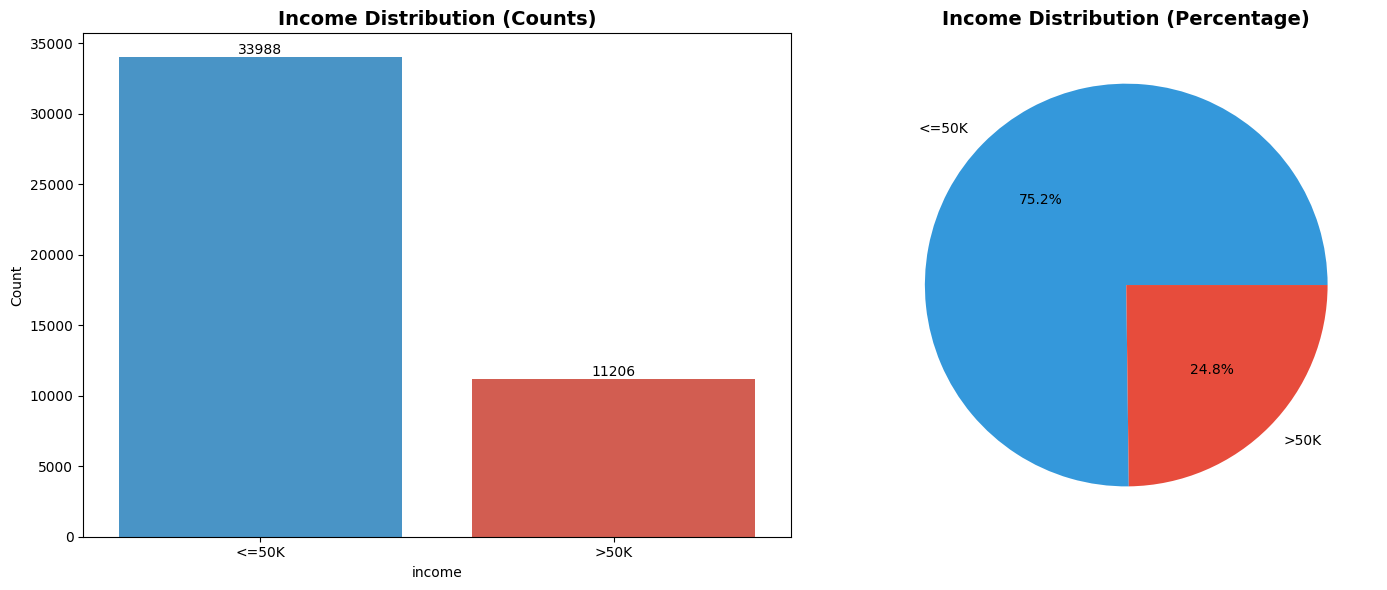

In [6]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Count plot
sns.countplot(data=df, x='income', palette=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('Income Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
           colors=['#3498db', '#e74c3c'])
axes[1].set_title('Income Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Univariate Analysis - Numerical Features

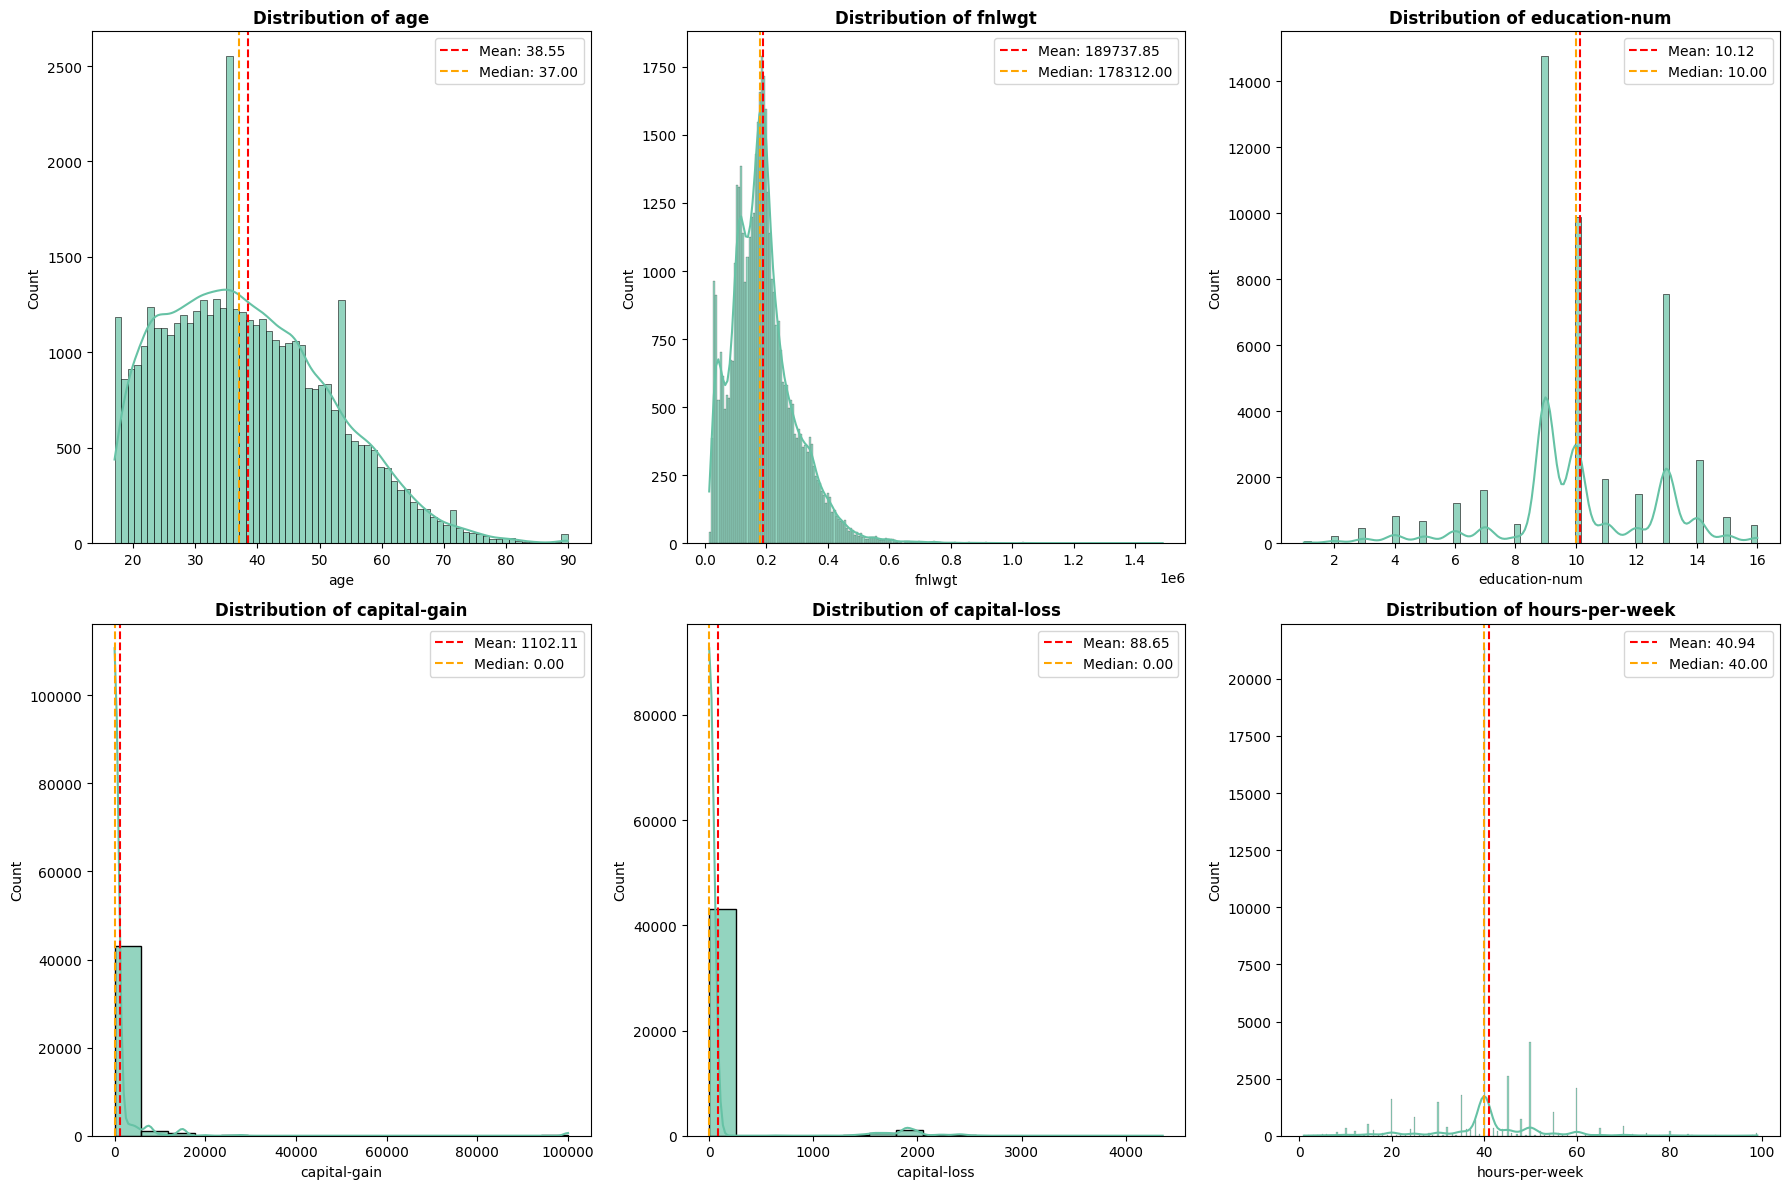

In [7]:
# Distribution plots
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
        axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.2f}')
        axes[i].legend()

# Remove empty subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Univariate Analysis - Categorical Features

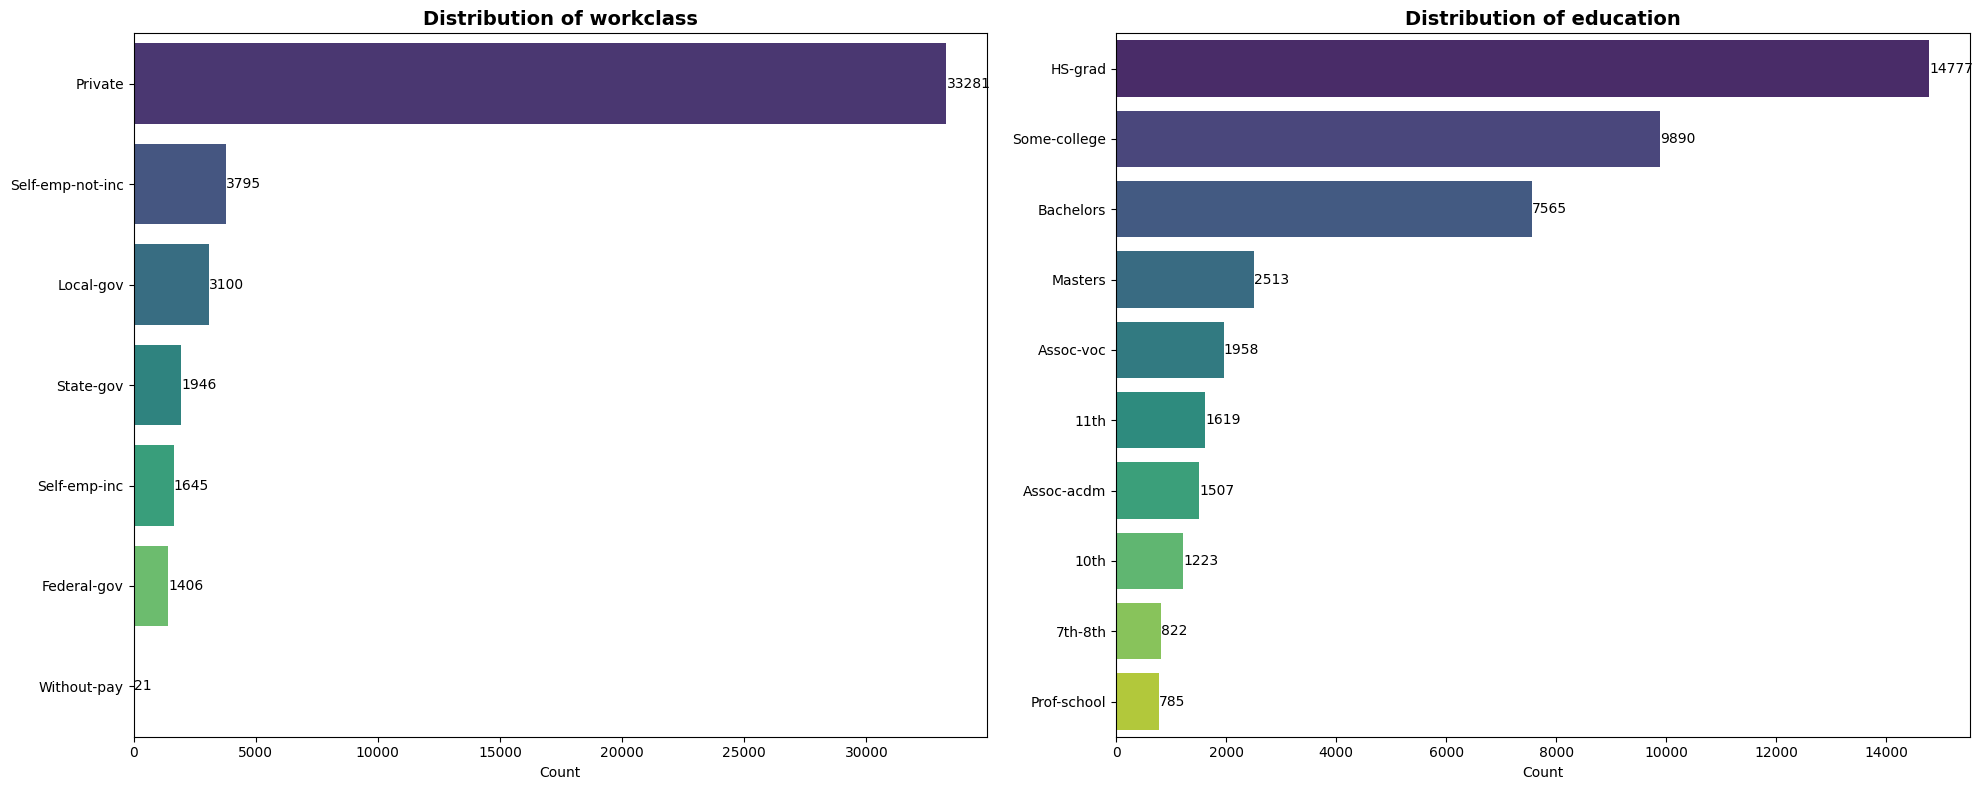

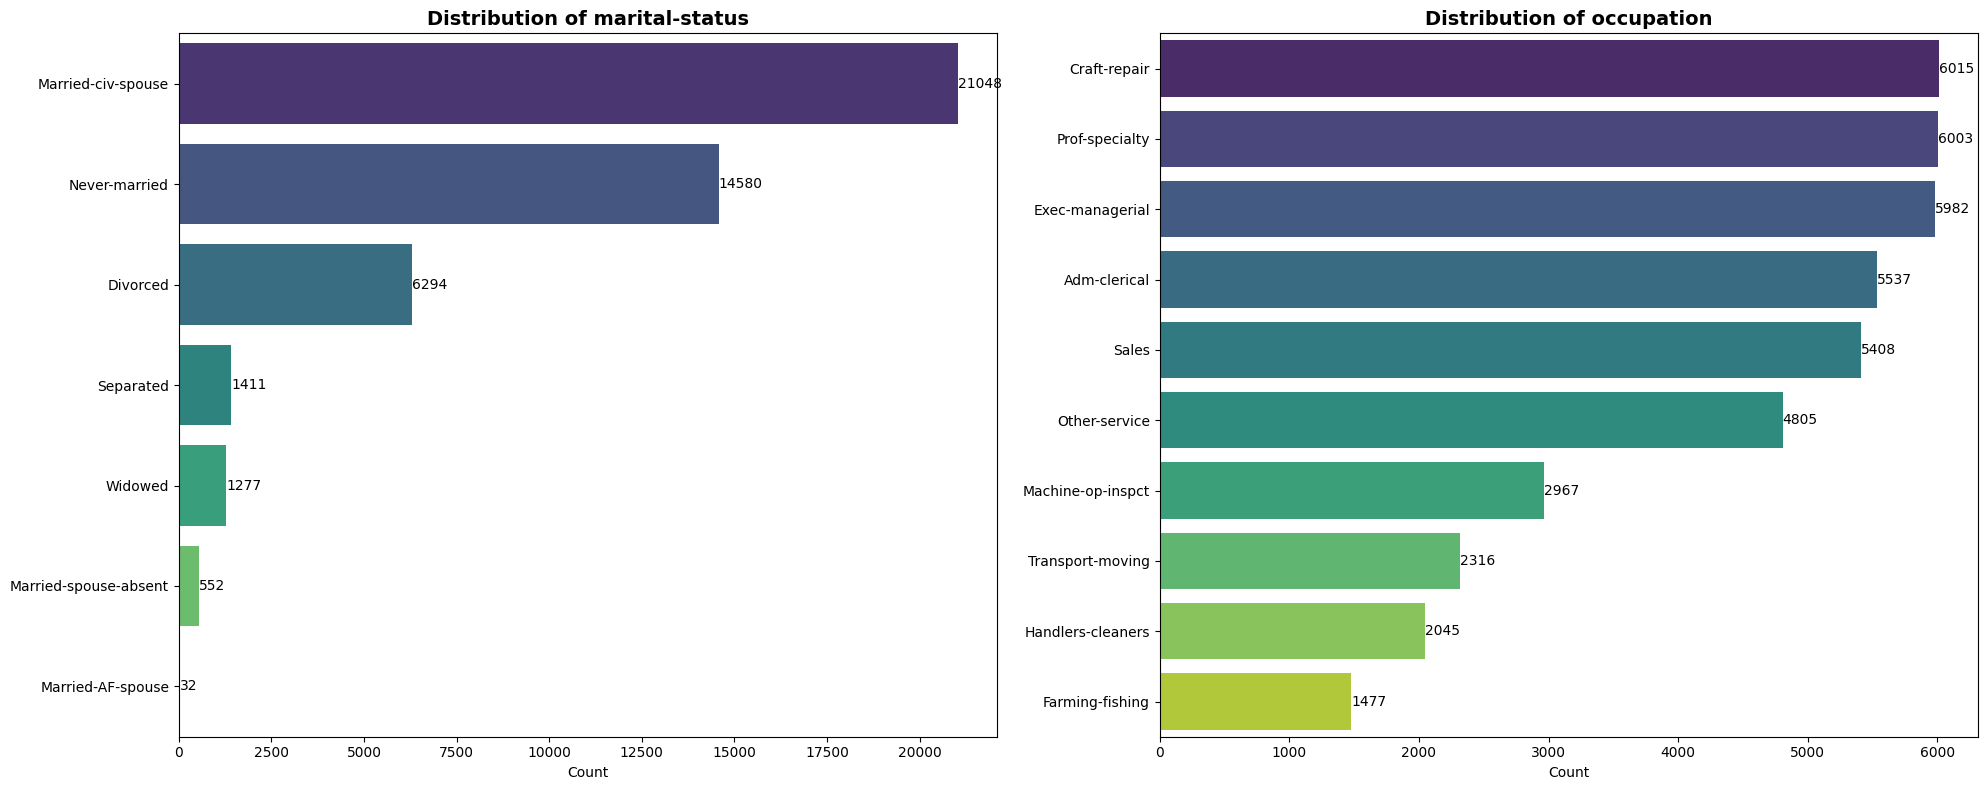

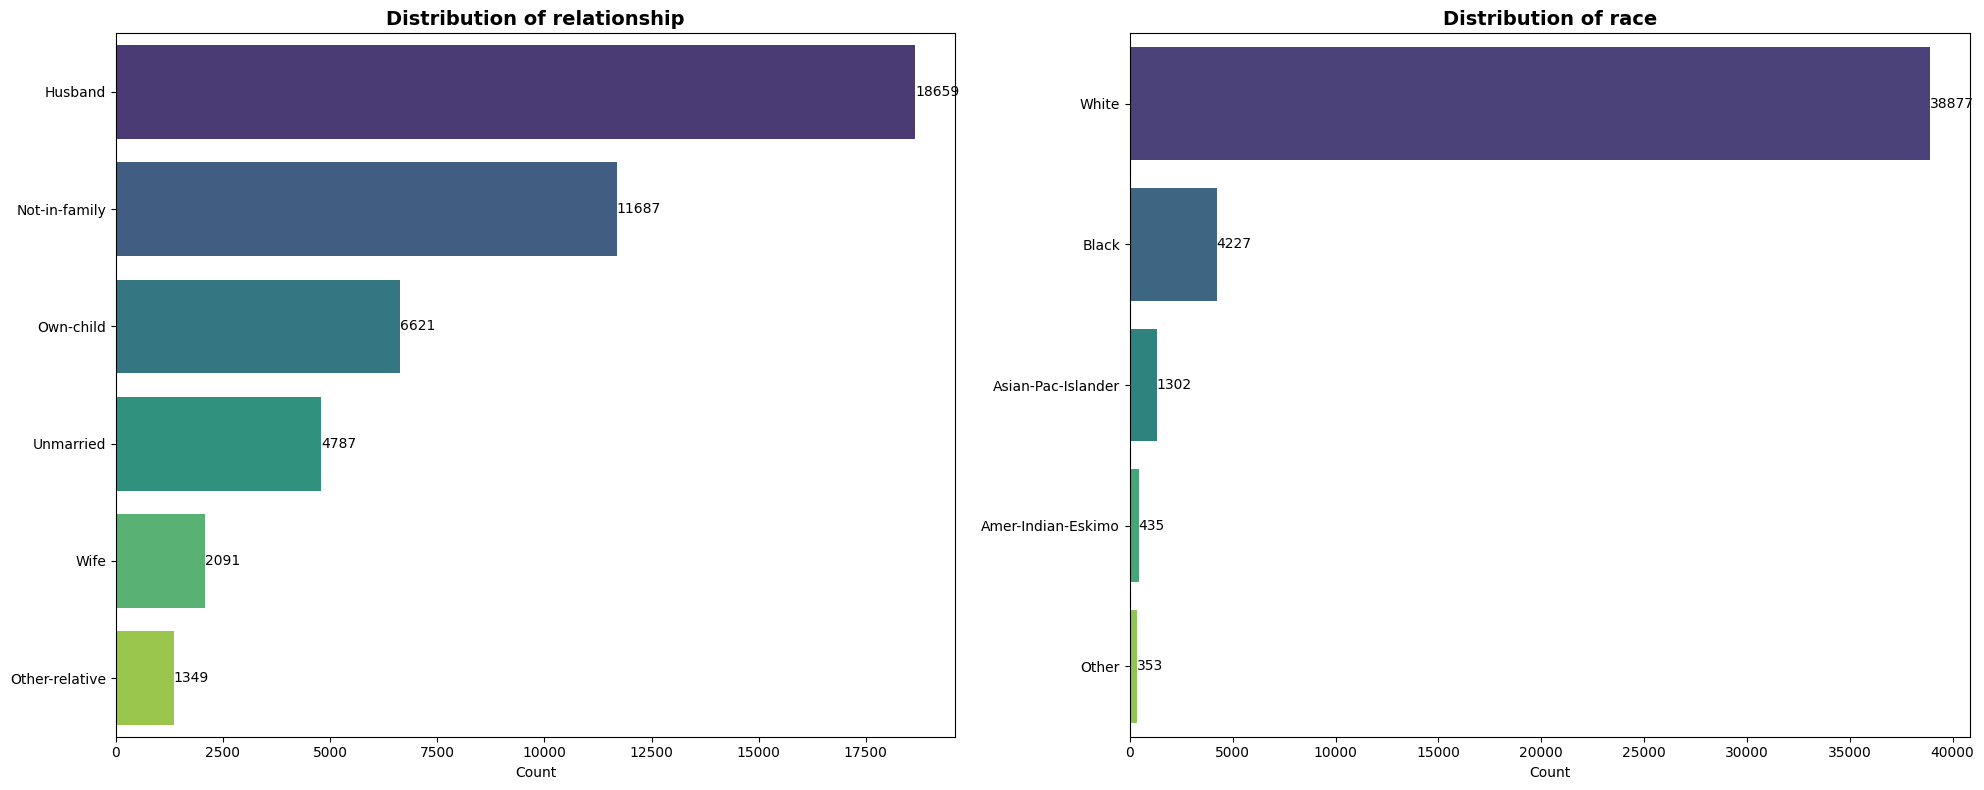

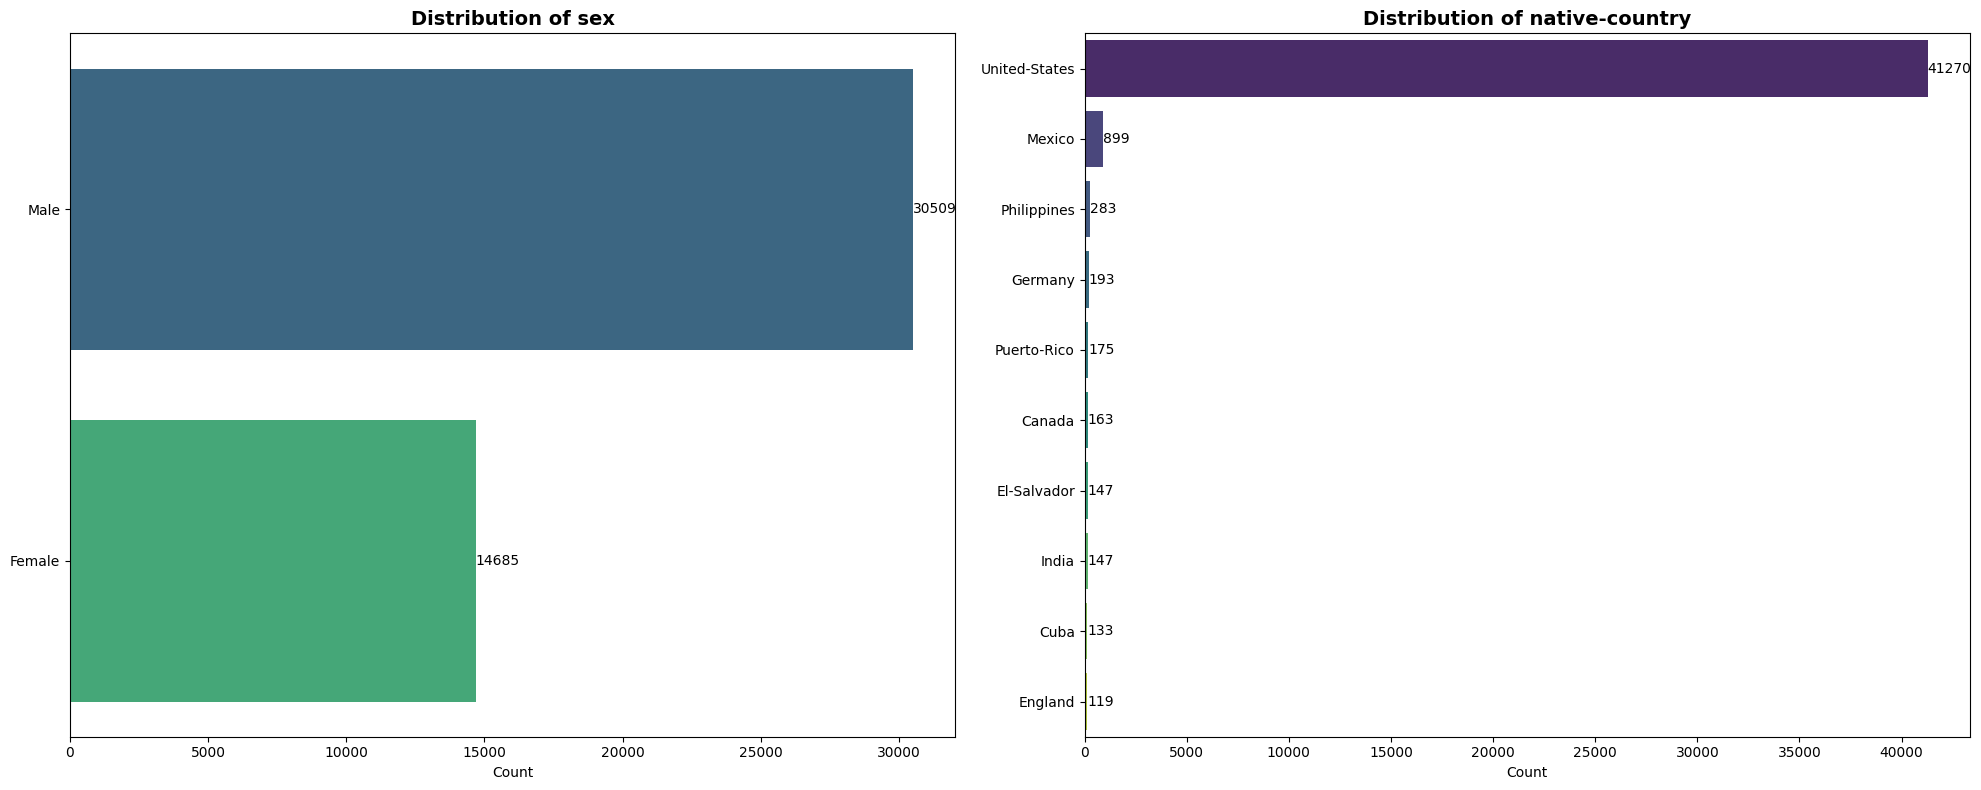

In [8]:
# Categorical features visualization
categorical_features = [col for col in categorical_cols if col != 'income']
n_features = len(categorical_features)

for i in range(0, n_features, 2):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    for j, ax in enumerate(axes):
        if i + j < n_features:
            col = categorical_features[i + j]
            value_counts = df[col].value_counts().head(10)  # Top 10 categories
            
            sns.barplot(x=value_counts.values, y=value_counts.index, ax=ax, palette='viridis')
            ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Count')
            
            # Add value labels
            for container in ax.containers:
                ax.bar_label(container)
        else:
            ax.remove()
    
    plt.tight_layout()
    plt.show()

## Bivariate Analysis - Numerical Features vs Income

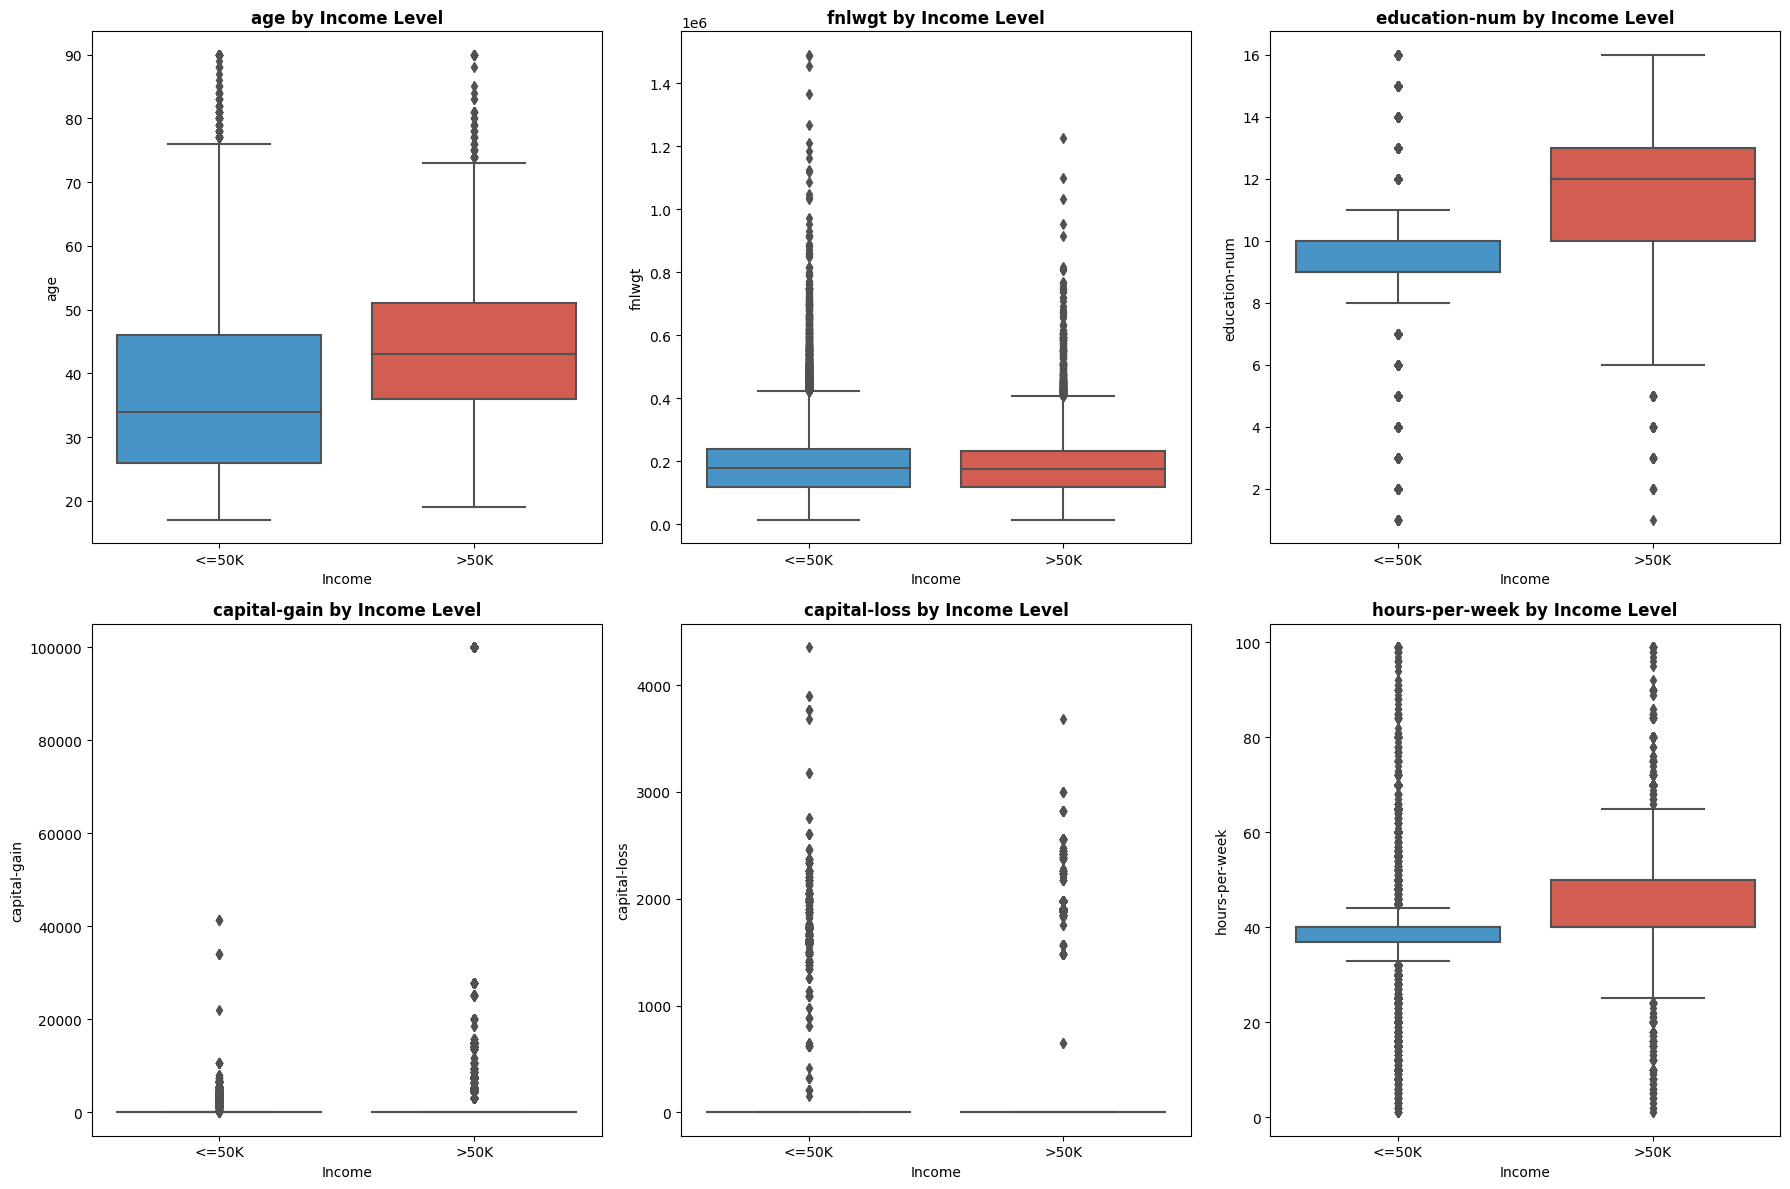

In [9]:
# Box plots for numerical features by income
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(data=df, x='income', y=col, 
                   palette={'<=50K': '#3498db', '>50K': '#e74c3c'}, ax=axes[i])
        axes[i].set_title(f'{col} by Income Level', fontweight='bold')
        axes[i].set_xlabel('Income')
        axes[i].set_ylabel(col)

# Remove empty subplots
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## Bivariate Analysis - Categorical Features vs Income

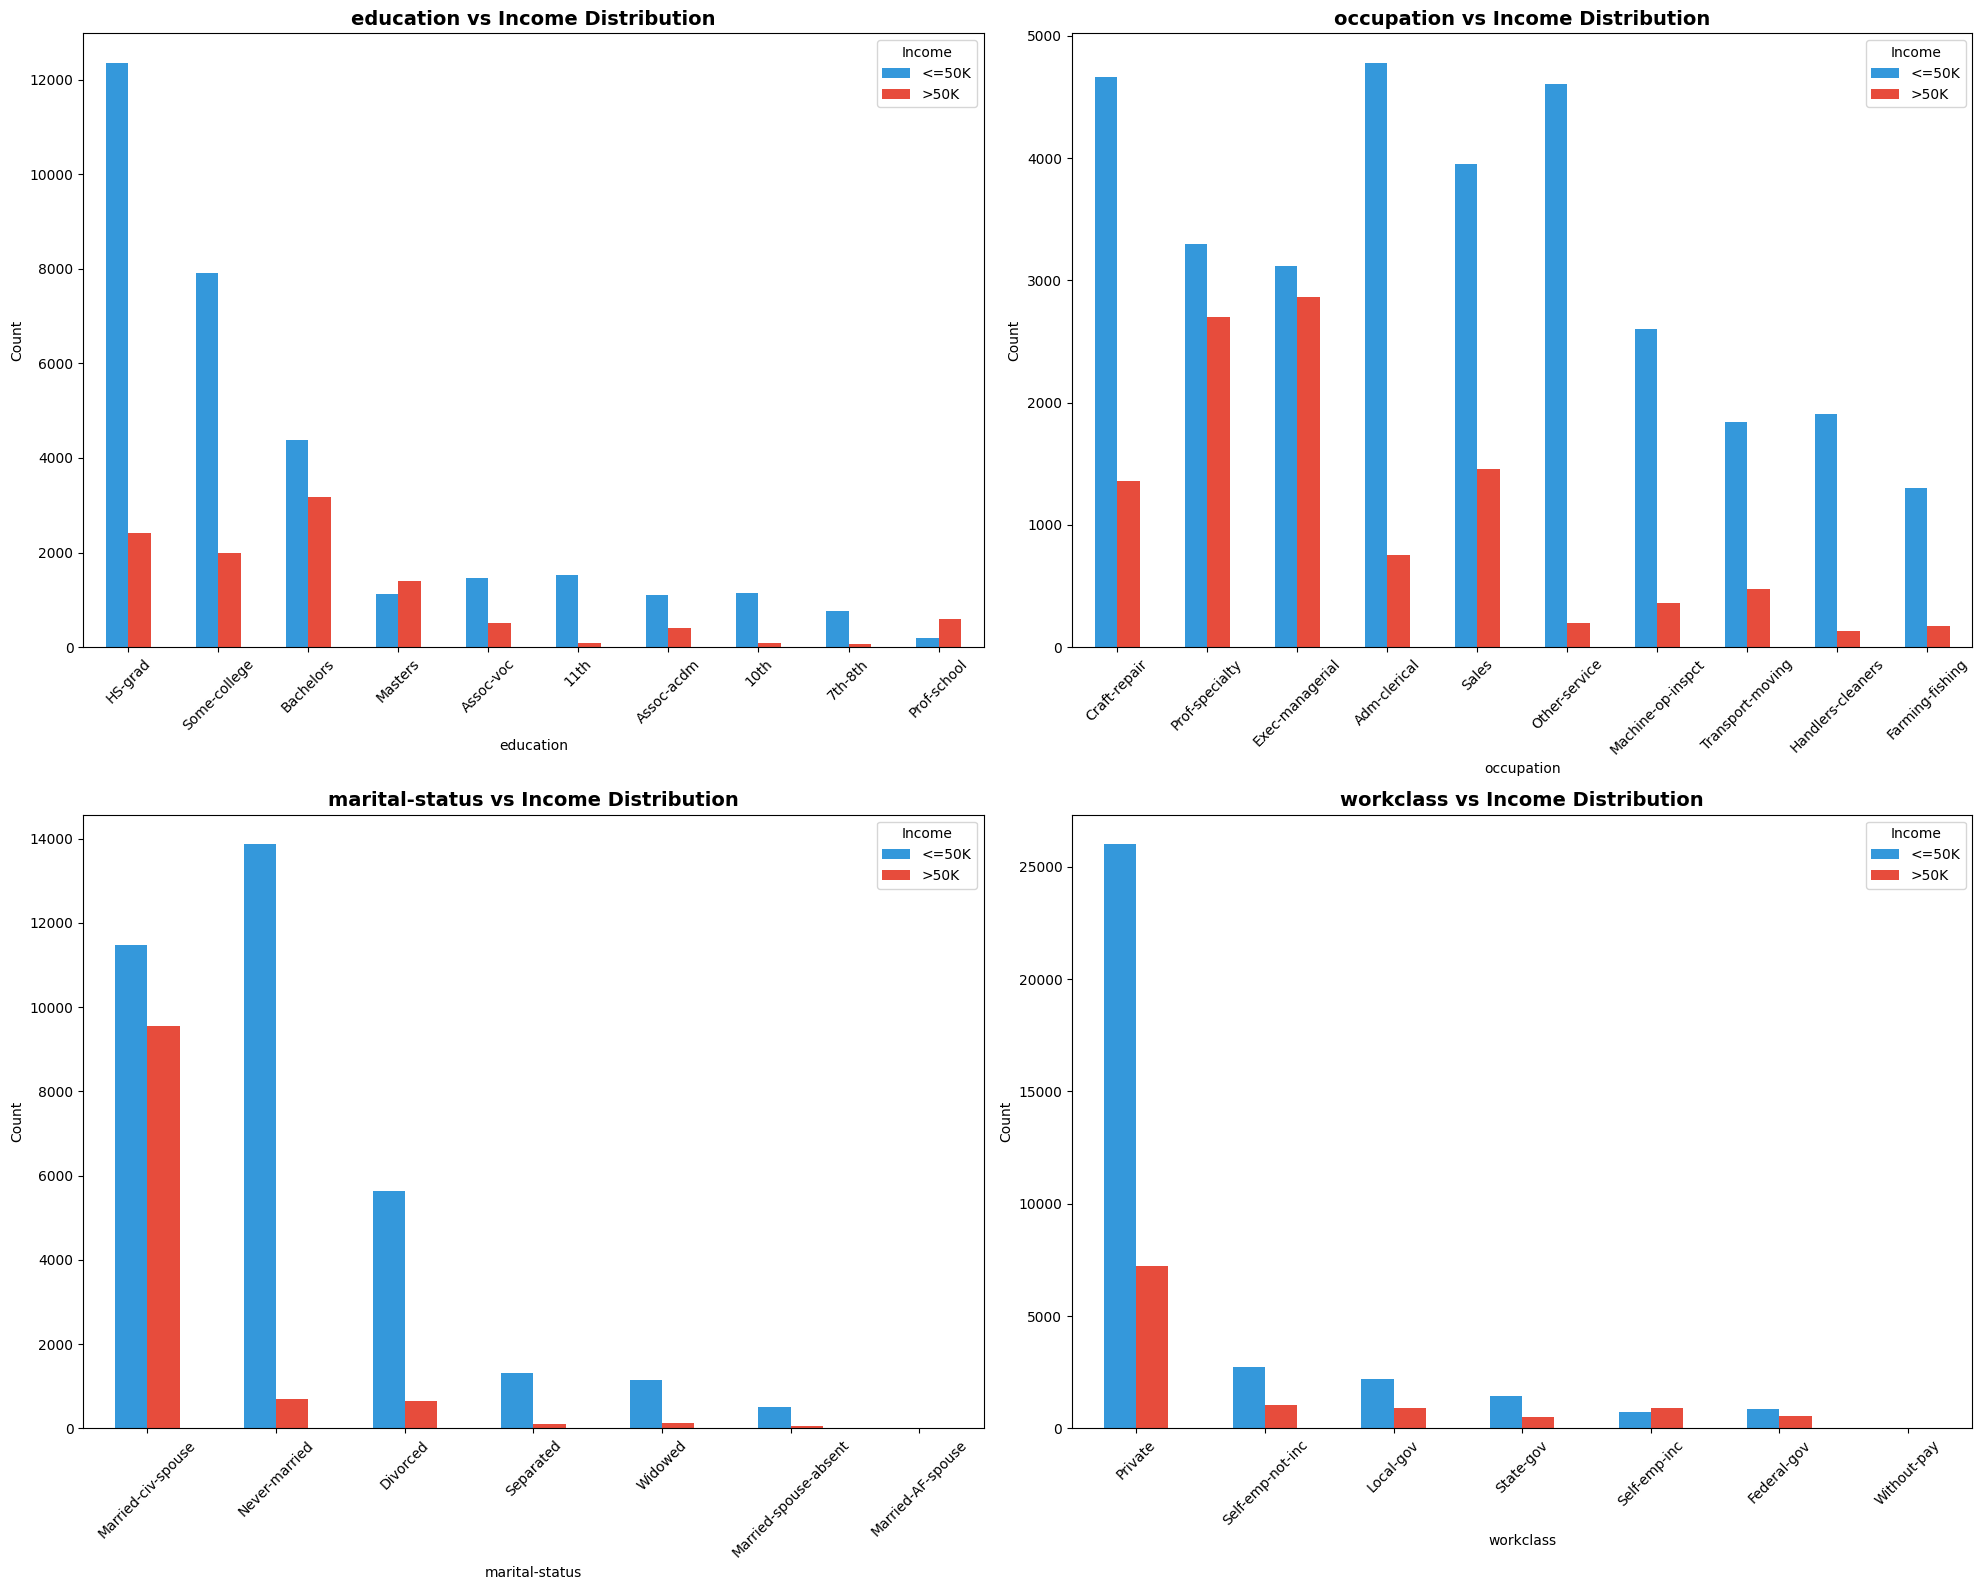

In [10]:
# Key categorical features visualization
key_features = ['education', 'occupation', 'marital-status', 'workclass']

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if col in df.columns:
        # Create crosstab for percentage calculation
        crosstab = pd.crosstab(df[col], df['income'])
        crosstab_pct = pd.crosstab(df[col], df['income'], normalize='index') * 100
        
        # Select top categories for readability
        top_categories = df[col].value_counts().head(10).index
        crosstab_subset = crosstab.loc[top_categories]
        
        crosstab_subset.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'])
        axes[i].set_title(f'{col} vs Income Distribution', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Income')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Education Analysis (Detailed)

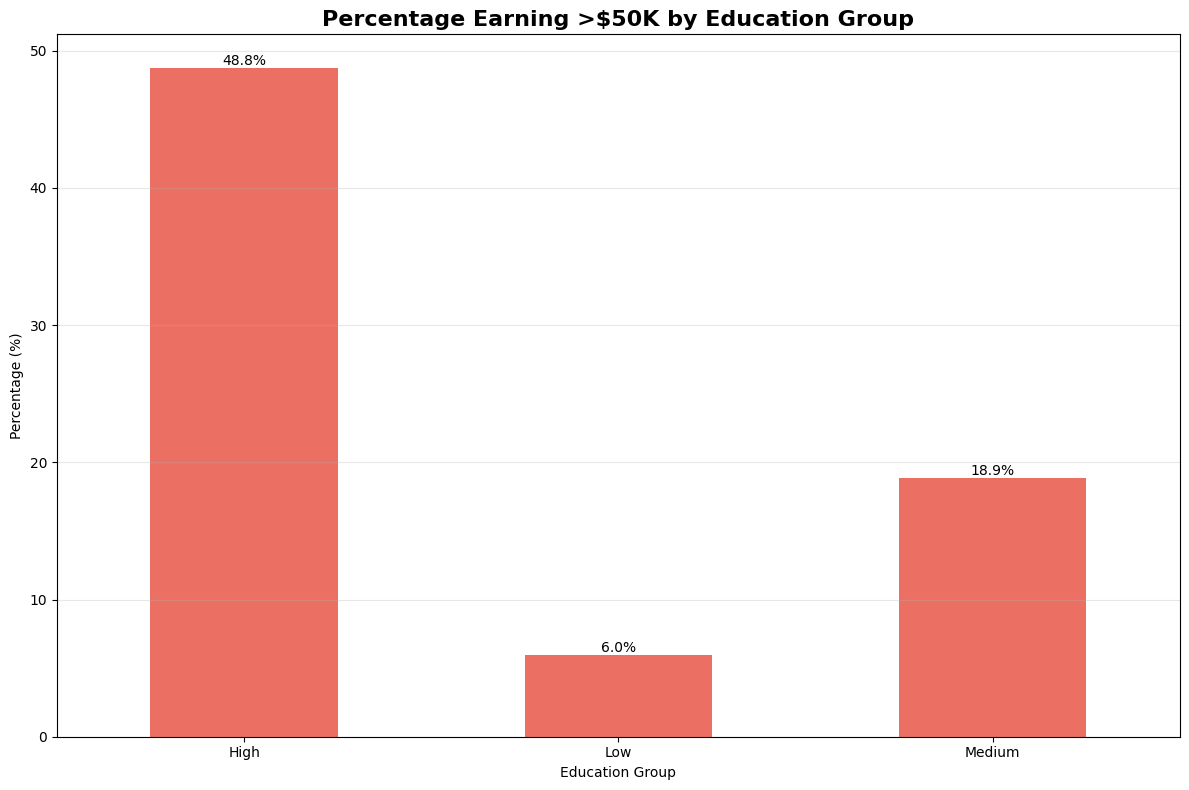

In [11]:
# Create education groups
education_groups = {
    'Low': ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th'],
    'Medium': ['HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm'], 
    'High': ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']
}

# Map education to groups
def map_education_group(education):
    for group, educations in education_groups.items():
        if education in educations:
            return group
    return 'Other'

df['education_group'] = df['education'].apply(map_education_group)

# Education group analysis
edu_income = pd.crosstab(df['education_group'], df['income'], normalize='index') * 100

# Visualization
plt.figure(figsize=(12, 8))
edu_income['>50K'].plot(kind='bar', color='#e74c3c', alpha=0.8)
plt.title('Percentage Earning >$50K by Education Group', fontsize=16, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Education Group')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

## Work Characteristics Analysis

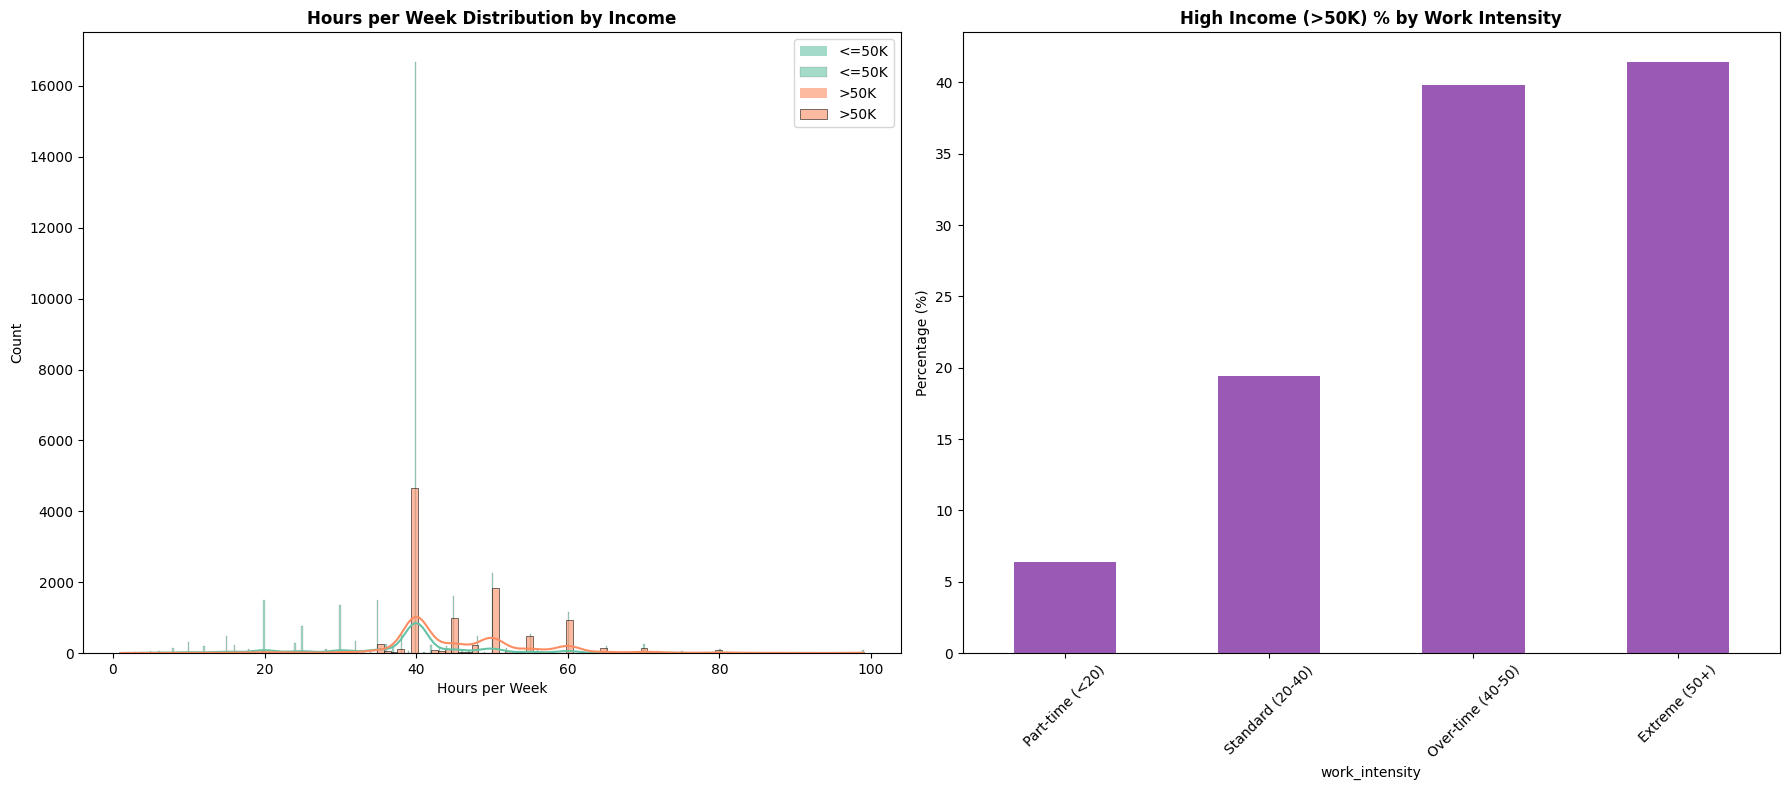

In [12]:
# Create work intensity groups
df['work_intensity'] = pd.cut(df['hours-per-week'], 
                             bins=[0, 20, 40, 50, 100], 
                             labels=['Part-time (<20)', 'Standard (20-40)', 
                                    'Over-time (40-50)', 'Extreme (50+)'])

# Work intensity vs income
work_income = pd.crosstab(df['work_intensity'], df['income'], normalize='index') * 100

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Hours distribution by income
for income in df['income'].unique():
    subset = df[df['income'] == income]
    sns.histplot(subset['hours-per-week'], alpha=0.6, label=income, ax=axes[0], kde=True)
axes[0].set_title('Hours per Week Distribution by Income', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Hours per Week')

# Work intensity vs high income percentage
work_income['>50K'].plot(kind='bar', ax=axes[1], color='#9b59b6')
axes[1].set_title('High Income (>50K) % by Work Intensity', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Correlation Analysis

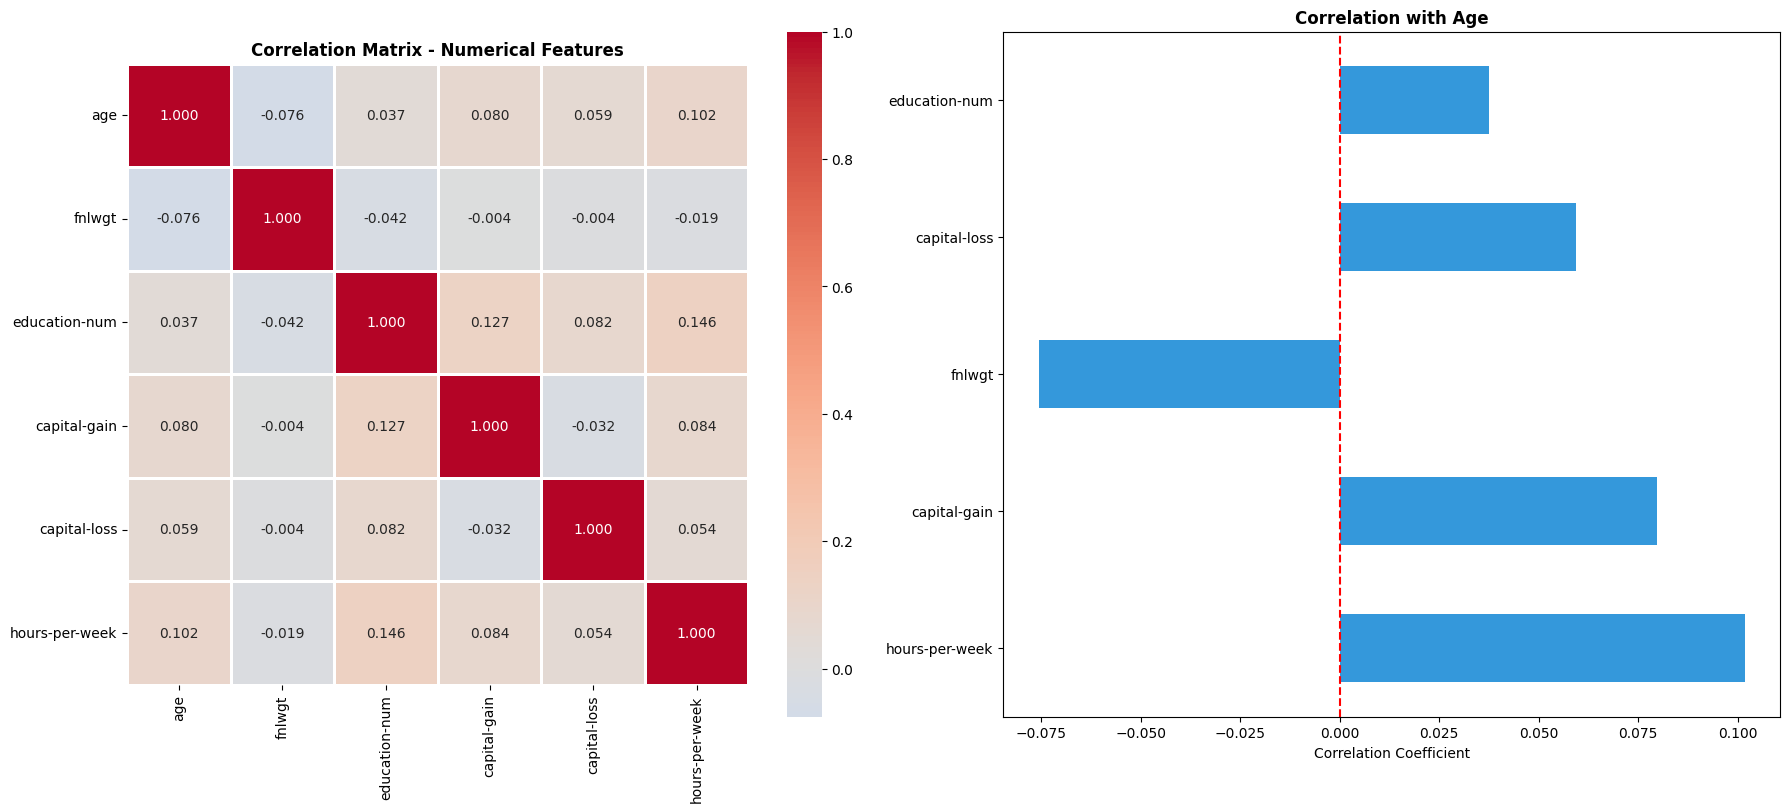

In [13]:
# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=2, fmt='.3f', ax=axes[0])
axes[0].set_title('Correlation Matrix - Numerical Features', fontweight='bold')

# Age correlation with other features
age_corr = correlation_matrix['age'].drop('age').sort_values(key=abs, ascending=False)
age_corr.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Correlation with Age', fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

## Demographics Analysis

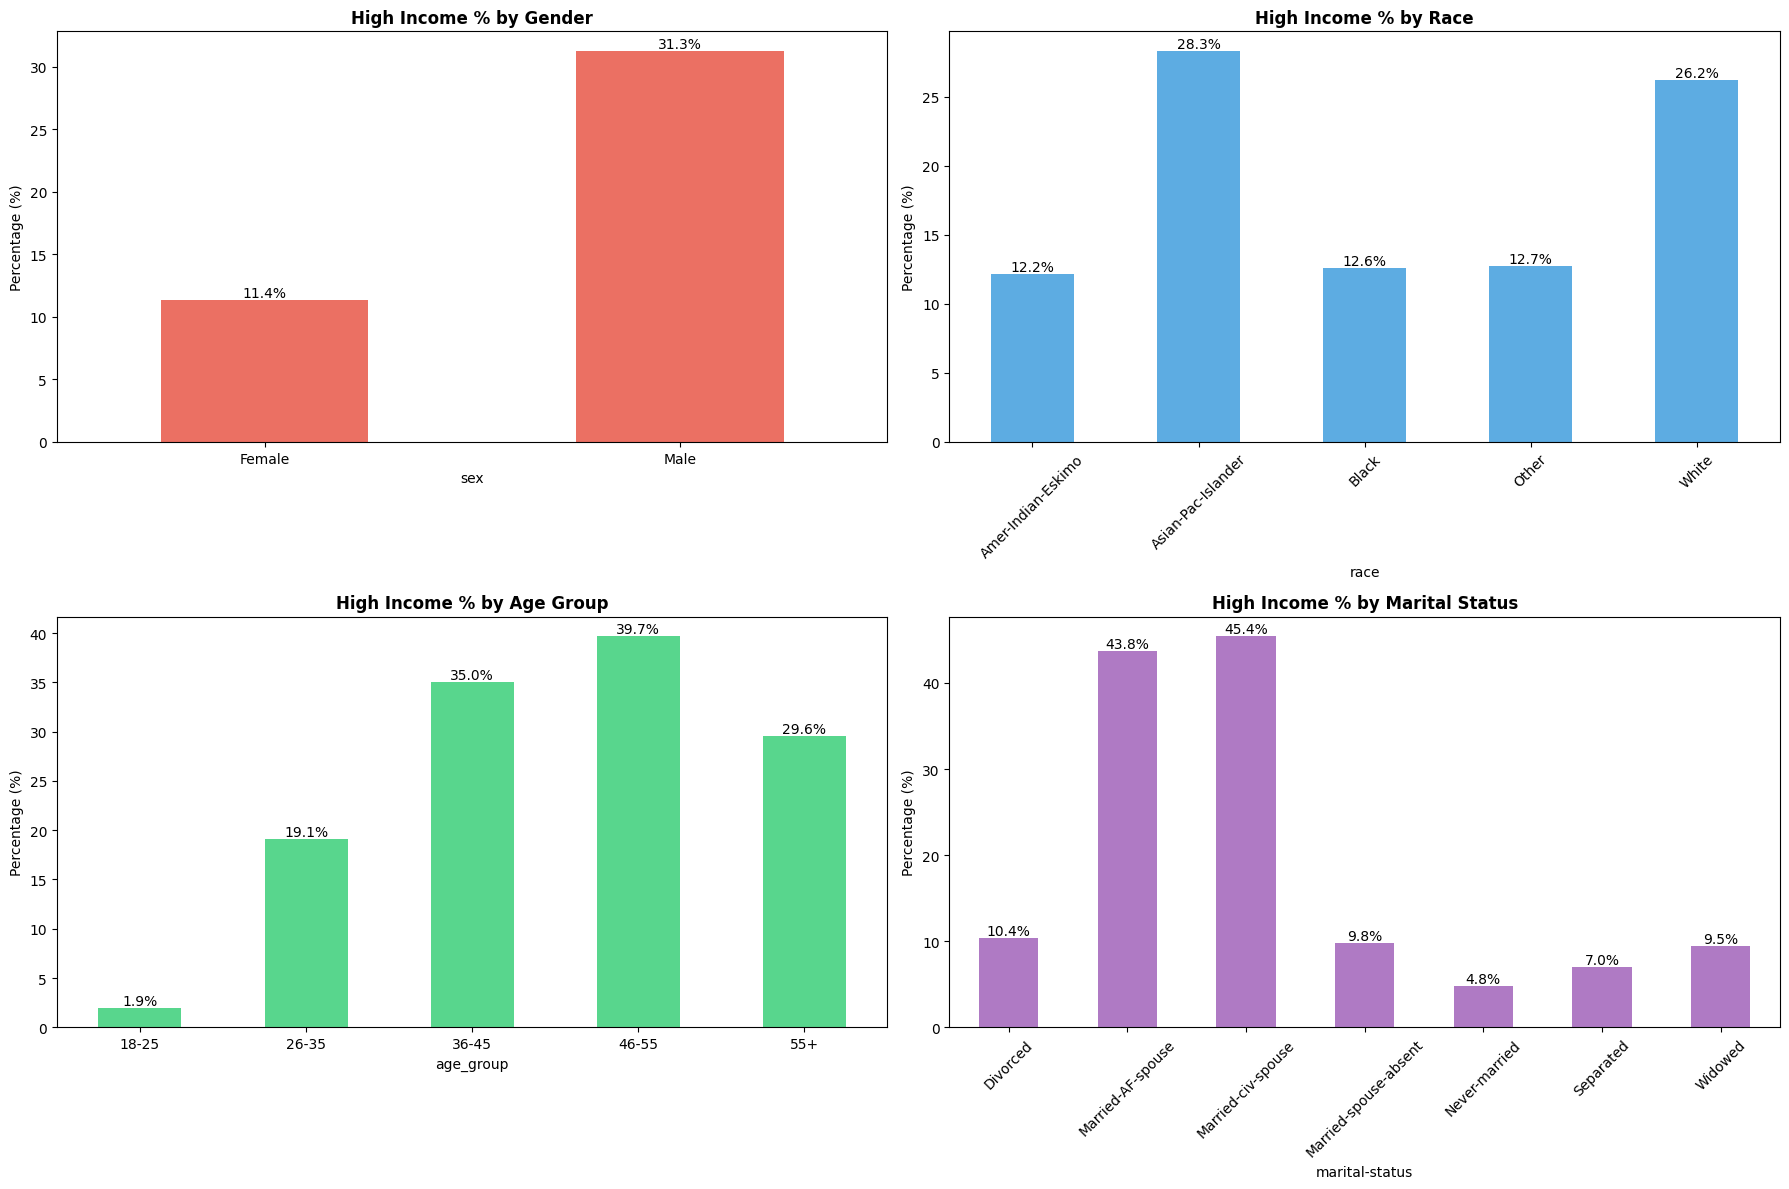

In [14]:
# Gender analysis
gender_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100

# Race analysis
race_income = pd.crosstab(df['race'], df['income'], normalize='index') * 100

# Age groups analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                        labels=['18-25', '26-35', '36-45', '46-55', '55+'])

age_income = pd.crosstab(df['age_group'], df['income'], normalize='index') * 100

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gender
gender_income['>50K'].plot(kind='bar', ax=axes[0,0], color='#e74c3c', alpha=0.8)
axes[0,0].set_title('High Income % by Gender', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)

# Race
race_income['>50K'].plot(kind='bar', ax=axes[0,1], color='#3498db', alpha=0.8)
axes[0,1].set_title('High Income % by Race', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Age group
age_income['>50K'].plot(kind='bar', ax=axes[1,0], color='#2ecc71', alpha=0.8)
axes[1,0].set_title('High Income % by Age Group', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

# Marital status
marital_income = pd.crosstab(df['marital-status'], df['income'], normalize='index') * 100
marital_income['>50K'].plot(kind='bar', ax=axes[1,1], color='#9b59b6', alpha=0.8)
axes[1,1].set_title('High Income % by Marital Status', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

# Add percentage labels
for ax in axes.flatten():
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')
    ax.set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()